In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dateutil.rrule import weekday
import seaborn as sns

# Preparing data
The data provided shows the trend over 1600 randomly selected observations over the past 3
years in the city of Washington. D.C. 
During the first stage of this project, we will learn more about the data, make decision in which data should be considered during the analytics, and remove the data with limited variability.

In [43]:
data=pd.read_csv('training_data_vt2025.csv')



The data.info() shows an abstract description of what type of data we are going to work with.
Among 1600 entries, there are no Null data and 15 Numeric type (8 float abd 7 integer).

In [44]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600 entries, 0 to 1599
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   hour_of_day     1600 non-null   int64  
 1   day_of_week     1600 non-null   int64  
 2   month           1600 non-null   int64  
 3   holiday         1600 non-null   int64  
 4   weekday         1600 non-null   int64  
 5   summertime      1600 non-null   int64  
 6   temp            1600 non-null   float64
 7   dew             1600 non-null   float64
 8   humidity        1600 non-null   float64
 9   precip          1600 non-null   float64
 10  snow            1600 non-null   int64  
 11  snowdepth       1600 non-null   float64
 12  windspeed       1600 non-null   float64
 13  cloudcover      1600 non-null   float64
 14  visibility      1600 non-null   float64
 15  increase_stock  1600 non-null   object 
dtypes: float64(8), int64(7), object(1)
memory usage: 200.1+ KB


In [45]:
data.head()

,hour_of_day,day_of_week,month,holiday,weekday,summertime,temp,dew,humidity,precip,snow,snowdepth,windspeed,cloudcover,visibility,increase_stock
0,5,5,1,0,0,0,-7.2,-15.0,53.68,0.0,0,0.0,16.3,31.6,16.0,low_bike_demand
1,21,4,1,0,1,0,-1.3,-12.8,40.97,0.0,0,0.0,23.9,85.7,16.0,low_bike_demand
2,21,3,8,0,1,1,26.9,21.8,73.39,0.0,0,0.0,0.0,81.1,16.0,low_bike_demand
3,1,6,1,0,0,0,3.1,-4.0,59.74,0.0,0,0.0,19.2,0.0,16.0,low_bike_demand
4,17,0,3,0,1,0,11.7,-11.4,18.71,0.0,0,0.0,10.5,44.6,16.0,low_bike_demand


In [46]:
data.describe()

,hour_of_day,day_of_week,month,holiday,weekday,summertime,temp,dew,humidity,precip,snow,snowdepth,windspeed,cloudcover,visibility
count,1600.00000,1600.000000,1600.000000,1600.000000,1600.000000,1600.00000,1600.000000,1600.000000,1600.000000,1600.000000,1600.0,1600.000000,1600.000000,1600.000000,1600.000000
mean,11.37125,3.022500,6.468750,0.033125,0.710000,0.64375,15.210313,7.750750,63.927844,0.122042,0.0,0.042713,13.082500,64.322375,15.344125
std,6.94837,2.012965,3.454741,0.179019,0.453904,0.47904,9.264785,10.026459,19.079419,0.920600,0.0,0.421198,7.756652,32.748869,2.323737
min,0.00000,0.000000,1.000000,0.000000,0.000000,0.00000,-9.100000,-18.400000,15.850000,0.000000,0.0,0.000000,0.000000,0.000000,0.100000
25%,5.00000,1.000000,3.000000,0.000000,0.000000,0.00000,7.700000,-0.800000,47.845000,0.000000,0.0,0.000000,7.500000,28.800000,16.000000
50%,12.00000,3.000000,6.000000,0.000000,1.000000,1.00000,15.500000,8.300000,65.175000,0.000000,0.0,0.000000,12.300000,79.300000,16.000000
75%,17.00000,5.000000,9.000000,0.000000,1.000000,1.00000,23.200000,16.800000,79.955000,0.000000,0.0,0.000000,17.600000,92.800000,16.000000
max,23.00000,6.000000,12.000000,1.000000,1.000000,1.00000,35.600000,24.300000,99.890000,25.871000,0.0,6.710000,43.800000,100.000000,16.000000


In [47]:
null_col=data.columns[data.isnull().any()]

for col in null_col:
    print(f"Column '{col}': {data[col].isnull().sum()} null values")



In [48]:

columns_to_check = ['holiday', 'weekday', 'summertime', 'snow', 'increase_stock']
for col in columns_to_check:
    print(f"Column:'{col}' is with a uniqe value of: {data[col].unique()}")



Column:'holiday' is with a uniqe value of: [0 1]
Column:'weekday' is with a uniqe value of: [0 1]
Column:'summertime' is with a uniqe value of: [0 1]
Column:'snow' is with a uniqe value of: [0]
Column:'increase_stock' is with a uniqe value of: ['low_bike_demand' 'high_bike_demand']


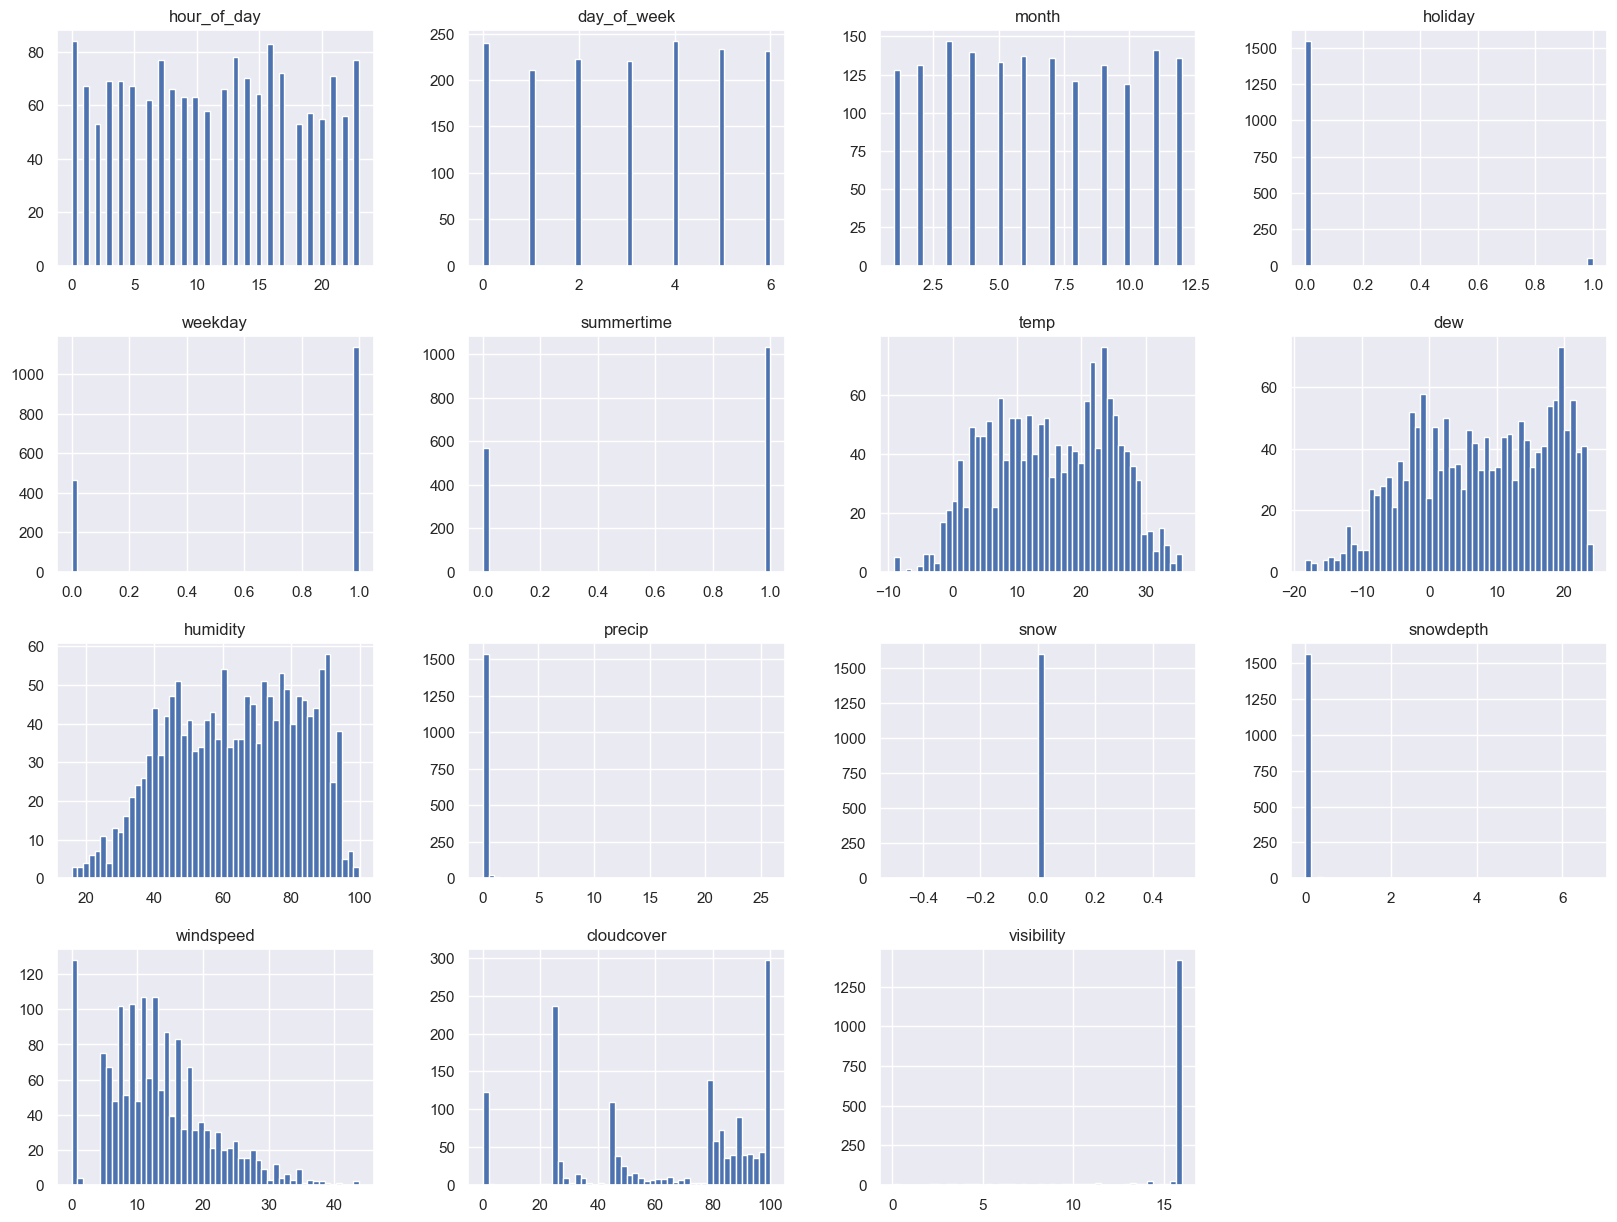

In [49]:
import matplotlib.pyplot as plt
data.hist(bins=50,figsize=(20,15),grid=True)
plt.show()


In [50]:
# sns.pairplot(data=data, hue="increase_stock")


# Notes regarding the variables
As shown on figure above, the variable snow, and snowdepth show no variability, therefore, they can be removed from further participation in analytics.
The remaining features can also be classified, regarding their 

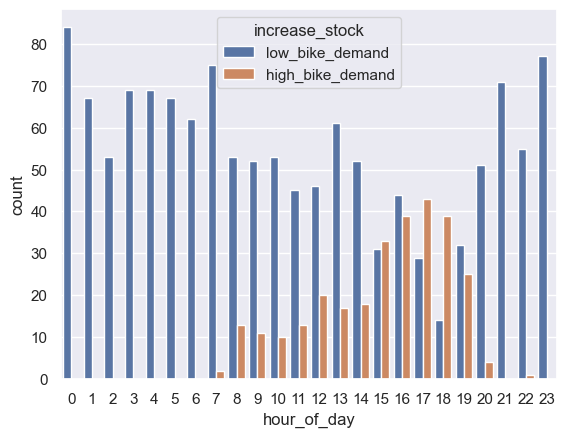

In [51]:
sns.countplot(x='hour_of_day', hue='increase_stock', data=data)
plt.show()

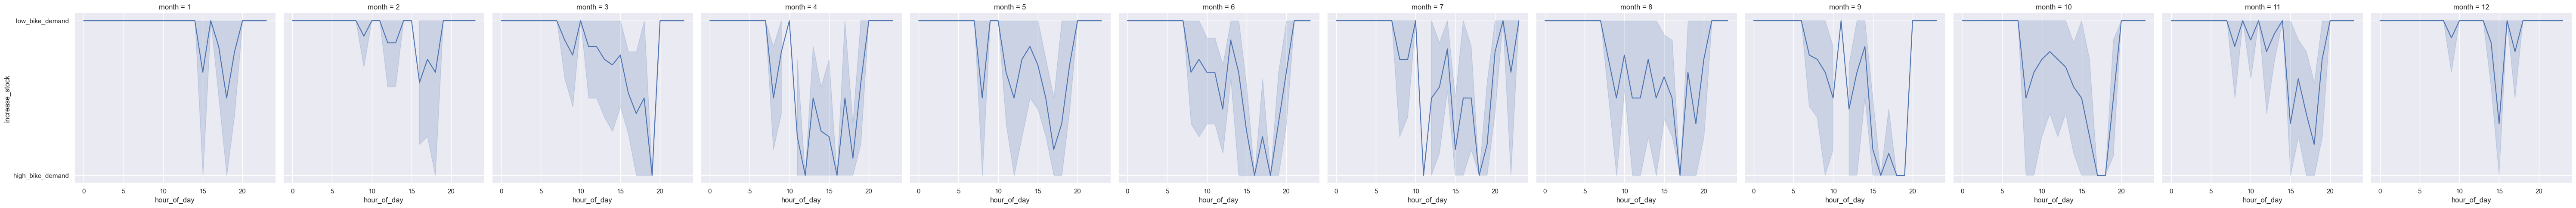

In [52]:

# Import seaborn
import seaborn as sns
import matplotlib.pyplot as plt

# Apply the default theme
sns.set_theme()
sns.relplot(data=data, x="hour_of_day", y="increase_stock",col="month", kind="line")


plt.show()

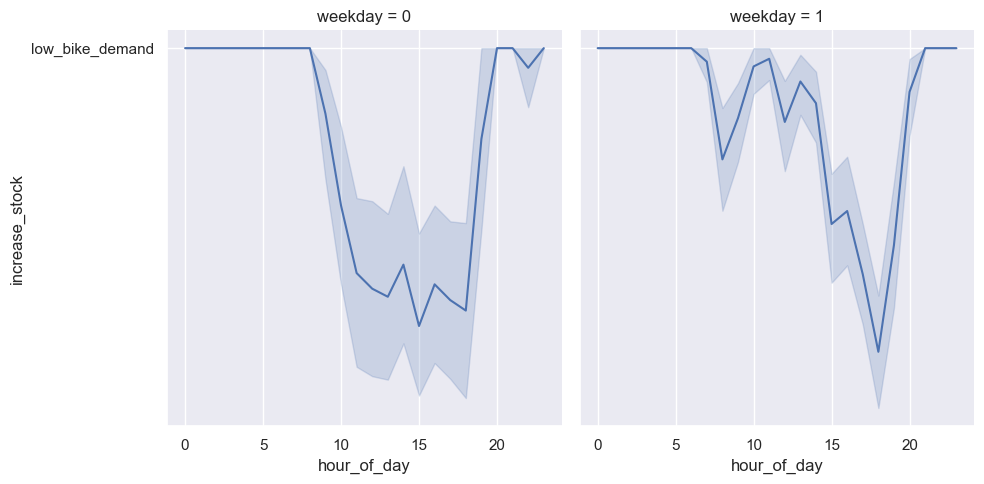

In [53]:
#Weekday and Weekends
sns.relplot(data=data, x="hour_of_day", y="increase_stock",col="weekday", kind="line")



ValueError: could not convert string to float: 'low_bike_demand'

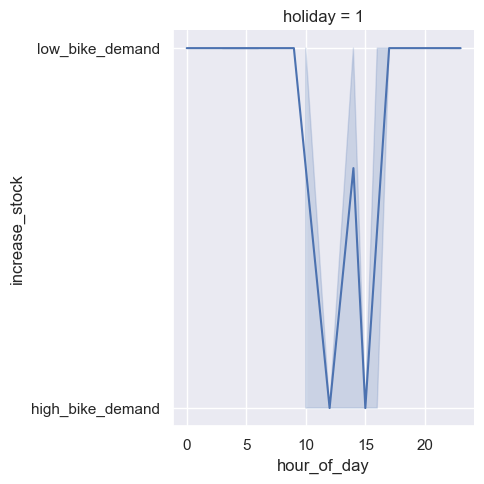

In [54]:
#Holiday
holiday_data=data[(data["holiday"]==1)]

sns.relplot(data=holiday_data, x="hour_of_day", y="increase_stock",col="holiday", kind="line")

sns.heatmap(data=holiday_data, annot=True, fmt='.2f')

# Trend analysis on weather type
<h1>Rain and precip</h1>



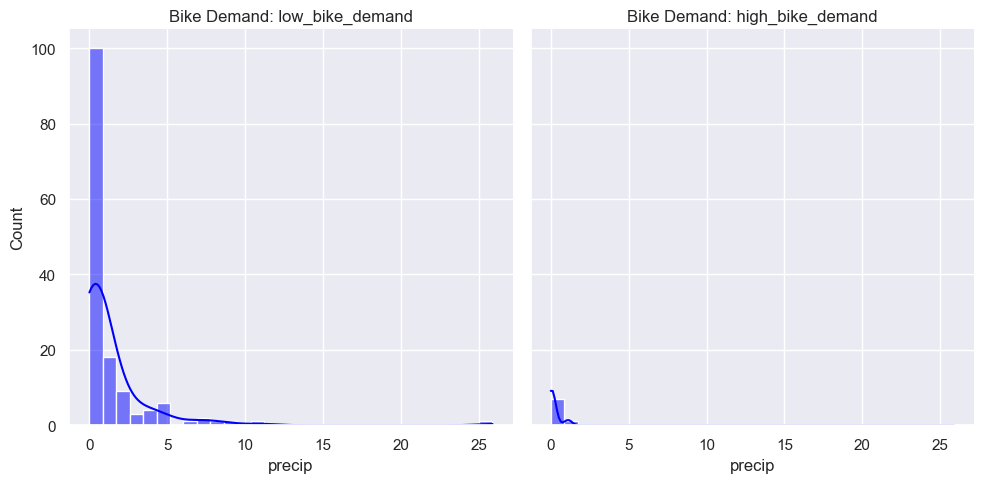

                  count      mean       std    min      25%     50%     75%  \
increase_stock                                                                
high_bike_demand    8.0  0.199875  0.375742  0.011  0.01775  0.0585  0.1475   
low_bike_demand   147.0  1.317469  2.772825  0.006  0.05800  0.4080  1.2525   

                     max  
increase_stock            
high_bike_demand   1.116  
low_bike_demand   25.871  


In [154]:
# Analyze precipitation distribution on rainy days
rainyday = data[data["precip"] > 0]

sns.displot(
    data=rainyday, 
    x="precip", 
    col="increase_stock", 
    kde=True, 
    bins=30, 
    color="blue"
).set_titles("Bike Demand: {col_name}")


plt.show()

# Summary statistics
print(rainyday.groupby("increase_stock")["precip"].describe())


# Temp
 

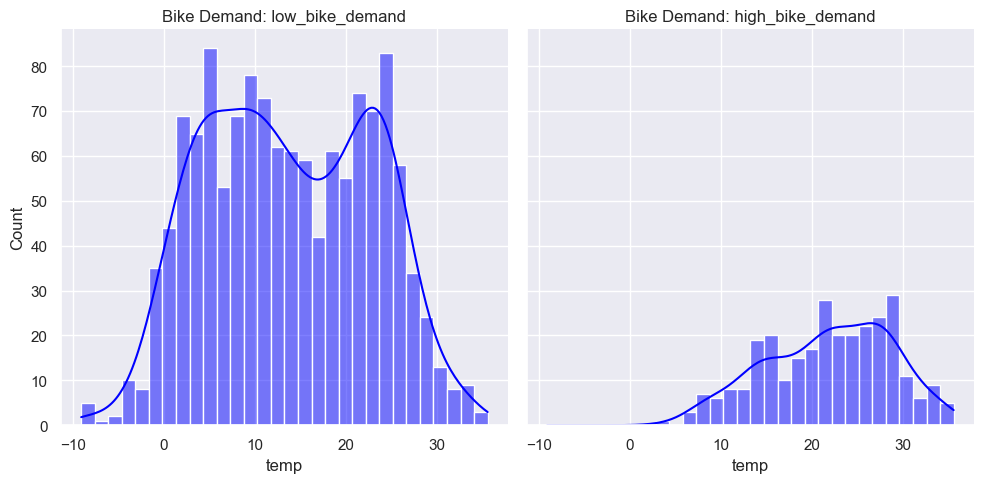

In [159]:

sns.displot(
    data=data, 
    x="temp", 
    col="increase_stock", 
    kde=True, 
    bins=30, 
    color="blue"
).set_titles("Bike Demand: {col_name}")


plt.show()




# Trend analysis on windspeed
<h2>Low bike demand</h2>
<pre>According to the Normal distribution graph, the majority of the decrease in bike demand occurs when the wind speed is around 5-15 km/h. As the wind speed increases, the frequency of low bike demand decreases which can be interpreted as less high speed occurred and it is less likely to be associated with low bike demand.</pre>
<h2>High bike demand</h2>
<pre>The wind speed distribution graph is more narrow around lower speed 5-10 km/h which suggests high bike demand in this area. </pre>
<br>

<pre>This analysis suggests wind speed affects bike demand. Low bike demand is more distributed across a wider range of wind speeds but peaks at a lowe speed. High bike demand graph indicates people are more likely to use bikes when the wind is mild, However, the number of decrease in bike demand was more reported in comparison to high demand. </pre>




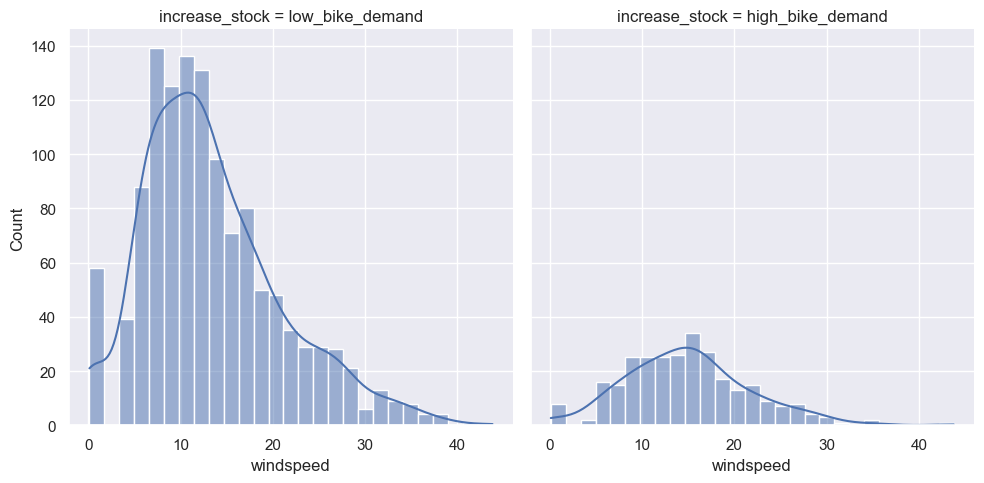

                   count       mean       std  min   25%   50%   75%   max
increase_stock                                                            
high_bike_demand   283.0  14.930742  6.798045  0.1  10.3  14.6  18.4  43.8
low_bike_demand   1251.0  13.354596  7.526876  0.1   7.8  12.2  17.6  43.7


In [158]:
windydays=data[(data["windspeed"]>0) ]


sns.displot(data=windydays, x="windspeed", col="increase_stock", kde=True)
plt.show()

# Summary statistics
print(windydays.groupby("increase_stock")["windspeed"].describe())





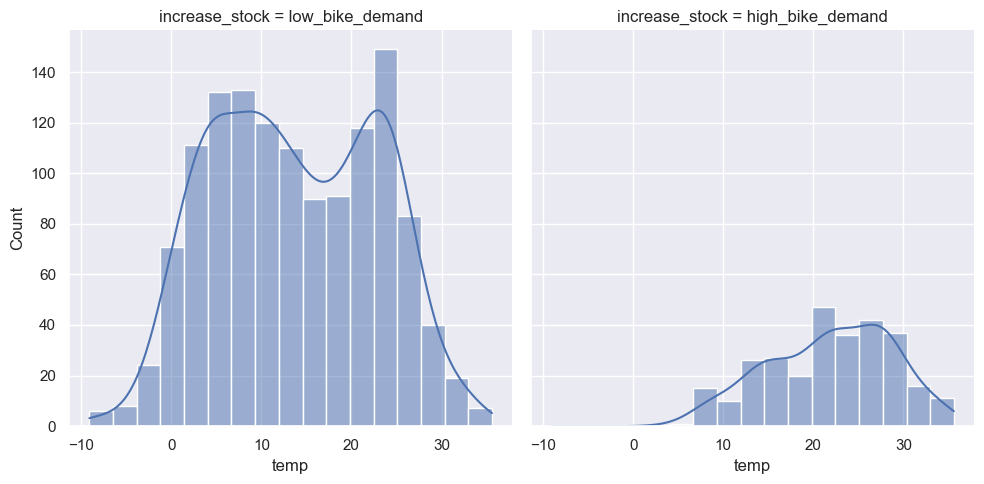

<h1>Discriminant analysis: LDA, QDA </h1>
<h2> abstraction of the problem</h2>

<h2>introduction</h1>



<p>LDA is a generative classifier model assumes the data is normaly distributed. This requires our data to be normalized since many of the features, including(Temp, Dew, Humidity, Windspeed, Cloudcover, Visibility) have a wide range of values. In addition, due to lack of variability and meaningfullness, we droped the Snow and Snow Depth.</p> We have chosen to procceed with two methods
<ul>
<li> Z-score
<li> Min-Max
</ul>
<h1> Z-score </h1>
<p> The standard deviation shows how much the data deviates from the mean. a small standar deviation makes the data less spread out around the mean.

In [55]:
from sklearn.preprocessing import StandardScaler
import pandas as pd
from scipy import stats


features_to_normalize = ['temp', 'dew', 'humidity', 'windspeed', 'cloudcover', 'visibility']

# Initialize scaler
scaler = StandardScaler()

# Fit and transform on training data
data[features_to_normalize] = scaler.fit_transform(data[features_to_normalize])
data[features_to_normalize].mean()

temp         -6.883383e-17
dew          -8.881784e-18
humidity     -5.329071e-17
windspeed     5.107026e-17
cloudcover    1.332268e-16
visibility    7.904788e-16
dtype: float64

<h2>data analysis</h2>
